In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import pickle

In [3]:
# loading the processed data

train_df = pd.read_csv("../data/processed/train_processed.csv")
test_df = pd.read_csv("../data/processed/test_processed.csv")

In [4]:
# Create tokenizer

VOCAB_SIZE = 2000

tokenizer = Tokenizer(
    num_words = VOCAB_SIZE,
    oov_token = "<OOV>"        # for words not seen during training
)


In [5]:
# Fit tokenizer

tokenizer.fit_on_texts(train_df["clean_text"])

In [6]:
# Number of unique words

len(tokenizer.word_index)

103847

In [7]:
# top words

list(tokenizer.word_index.items())[:20]

[('<OOV>', 1),
 ('the', 2),
 ('and', 3),
 ('a', 4),
 ('i', 5),
 ('to', 6),
 ('was', 7),
 ('of', 8),
 ('it', 9),
 ('for', 10),
 ('in', 11),
 ('n', 12),
 ('is', 13),
 ('that', 14),
 ('my', 15),
 ('but', 16),
 ('we', 17),
 ('this', 18),
 ('with', 19),
 ('they', 20)]

In [8]:
# convert text to sequences

train_sequences = tokenizer.texts_to_sequences(train_df["clean_text"])
test_sequences = tokenizer.texts_to_sequences(test_df["clean_text"])

In [11]:
# inspect sequences

print(train_df["clean_text"].iloc[0])
print(train_sequences[0])

good food for a buffet chain. extensive salad and dessert section. kids love love love the chocolate fountain and cotton candy. \nokay fine, you got me - even i love the chocolate fountain and cotton candy, happy? best part of the place.\n\nbut need to bring up a few cons:\n- dear gc... wash your shiz. all of it. i mean it. plates, silverware, cups - everything, gross gross gross, all the time. i usually have to go through 3 or 4 plate selections before i find one without a speck of old food on it. get kanye and his golddigger to roll up their sleeves and do the dishes in the back... they'd probably be better than who you have now.\n\n- the whole 'get your drink before you pay' thing is so annoying. it slows the (always endless) line down, makes it hard for people to hold a drink while digging through their purses for money, and makes it hard for the waiters to have to refill the drinks for you during your meal. \n\ntips:\n- if you want to go for dinner and not have to wait a half hour

In [16]:
# examine the sequence lengths

sequence_lengths = [len(seq) for seq in train_sequences]
pd.Series(sequence_lengths).describe()
    
    

count    100000.000000
mean        137.293650
std         124.564374
min           0.000000
25%          53.000000
50%         101.000000
75%         180.000000
max        1047.000000
dtype: float64

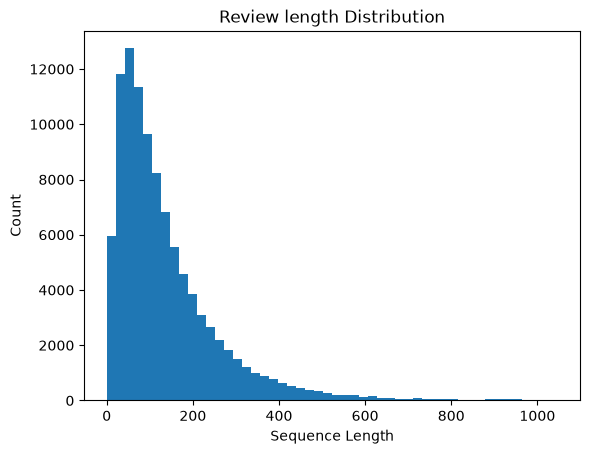

In [ ]:
# plot 

plt.hist(sequence_lengths, bins = 50)
plt.xlabel("Sequence Length")
plt.ylabel("Count")
plt.title("Review length Distribution")
plt.show()

In [18]:
# Padding

MAX_LENGTH = 150

X_train = pad_sequences(
    train_sequences,
    maxlen = MAX_LENGTH,
    padding = "post",
    truncating = "post"
)

X_test = pad_sequences(
    test_sequences,
    maxlen = MAX_LENGTH,
    padding = "post",
    truncating = "post"
)



In [21]:
# prepare labels

y_train = train_df["label"].values
y_test = test_df["label"].values

In [23]:
# save the tokenizer

with open("../models/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [25]:
# save the processed arrays

np.save("../data/tokenized/X_train.npy", X_train)
np.save("../data/tokenized/X_test.npy", X_test)

np.save("../data/tokenized/y_train.npy", y_train)
np.save("../data/tokenized/y_test.npy", y_test)